# Week 4: Implement & Analyze Data Science Workflow and Processing Pipeline Stages

## Problem Definition

In [1]:
objective = "Classification: Survived (Yes/No)"
success_criteria = "Accuracy > 80%"
constraints = "Limited features, missing values, imbalanced classes"
print("Objective:", objective)
print("Success Criteria:", success_criteria)
print("Constraints:", constraints)

Objective: Classification: Survived (Yes/No)
Success Criteria: Accuracy > 80%
Constraints: Limited features, missing values, imbalanced classes


## Data Collection

In [2]:
import pandas as pd
import seaborn as sns
df = sns.load_dataset('titanic')
print("Data shape:", df.shape)
print(df.head())

Data shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## Data Cleaning & Preprocessing

In [3]:
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.drop_duplicates(inplace=True)
df = pd.get_dummies(df, columns=['sex','class','embarked'], drop_first=True)
df['family_size'] = df['sibsp'] + df['parch']
print(df.head())

   survived  pclass   age  sibsp  parch     fare    who  adult_male deck  \
0         0       3  22.0      1      0   7.2500    man        True  NaN   
1         1       1  38.0      1      0  71.2833  woman       False    C   
2         1       3  26.0      0      0   7.9250  woman       False  NaN   
3         1       1  35.0      1      0  53.1000  woman       False    C   
4         0       3  35.0      0      0   8.0500    man        True  NaN   

   embark_town alive  alone  sex_male  class_Second  class_Third  embarked_Q  \
0  Southampton    no  False      True         False         True       False   
1    Cherbourg   yes  False     False         False        False       False   
2  Southampton   yes   True     False         False         True       False   
3  Southampton   yes  False     False         False        False       False   
4  Southampton    no   True      True         False         True       False   

   embarked_S  family_size  
0        True            1  
1   

C:\Users\aksha\AppData\Local\Temp\ipykernel_34976\898163243.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\aksha\AppData\Local\Temp\ipykernel_34976\898163243.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

## Exploratory Data Analysis (EDA)

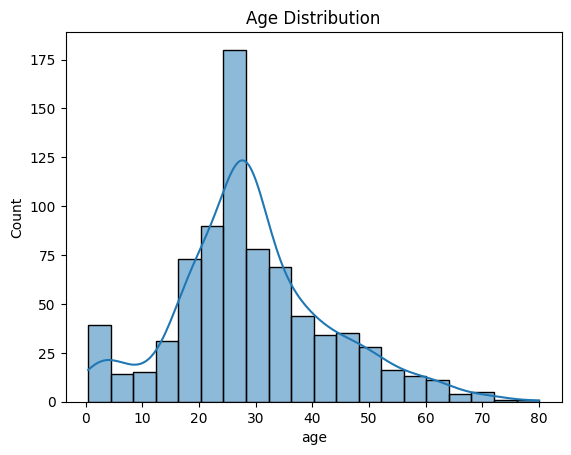

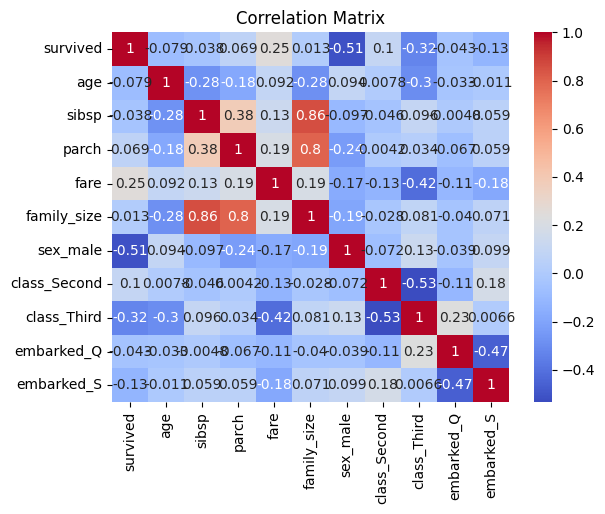

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

numeric_cols = ['survived', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'sex_male', 'class_Second', 'class_Third', 'embarked_Q', 'embarked_S']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Data Modeling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

features = ['age', 'sibsp', 'parch', 'fare', 'family_size', 'sex_male', 'class_Second', 'class_Third', 'embarked_Q', 'embarked_S']
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Evaluation

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7898089171974523
Precision: 0.7966101694915254
Recall: 0.6911764705882353
Confusion Matrix:
 [[77 12]
 [21 47]]
